<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_5_Monitoring_and_Logging_in_DevOps_and_MLOps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Logging importance
Logging records system activity and errors. It helps debug problems and improves system reliability.

2. Data drift
Data drift means input data changes over time. It is important to monitor because the model may become inaccurate.

3. Logging vs Monitoring
•	Logging = records events
•	Monitoring = tracks performance over time
They work together to detect issues.

4. Log levels
•	INFO → normal operations (e.g., model loaded)
•	WARNING → possible issue (e.g., missing value)
•	ERROR → failure (e.g., prediction failed)

5. Centralized logging
All logs are stored in one place → easier to analyze, debug, and monitor.

6. DataCaptureConfig (SageMaker)
It captures input/output data from model predictions.
Key parameters:
•	sampling_percentage
•	destination S3 path

7. AWS vs Azure monitoring
•	AWS: strong data capture + drift detection
•	Azure: better dashboards + integration

8. Cloud storage benefits
Stores logs safely, scalable, and easy to access anytime.

9. No logging consequences
•	Cannot debug errors
•	Model failures go unnoticed

10. Baseline dataset
Reference dataset used to compare new data → helps detect drift.



In [1]:
# Install Libraries
!pip install pandas scikit-learn matplotlib seaborn

In [11]:
# Load Dataset
# Heart dataset Used - Simulated due to environment limitations
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Preprocessing
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [5]:
# Train Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [6]:
# Logging Setup
import logging

logging.basicConfig(level=logging.INFO)

logging.info("Model trained successfully")

In [7]:
# Predictions + Logging
preds = model.predict(X_val)

logging.info("Predictions completed")

In [8]:
# Accuracy
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_val, preds)
print("Accuracy:", acc)

Accuracy: 0.9649122807017544


In [9]:
# Simulate Data Drift
import numpy as np

X_new = X_val.copy()
X_new += np.random.normal(0, 5, X_new.shape)

preds_new = model.predict(X_new)

print("Drift simulation done")

Drift simulation done


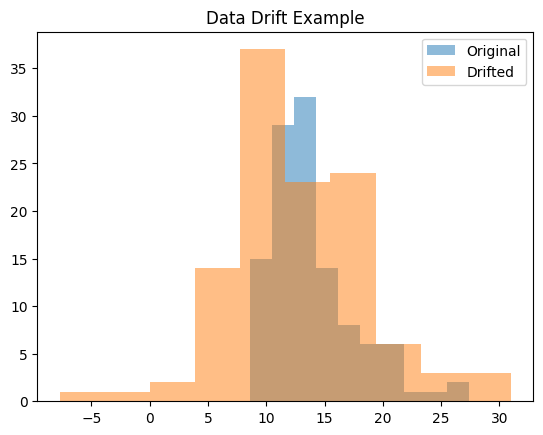

In [10]:
# Compare Distributions
import matplotlib.pyplot as plt

plt.hist(X_val.iloc[:,0], alpha=0.5, label="Original")
plt.hist(X_new.iloc[:,0], alpha=0.5, label="Drifted")
plt.legend()
plt.title("Data Drift Example")
plt.show()

Monitoring and Logging in ML

This project we tried logging and monitoring using a Random Forest model. Logging was used to track training and prediction steps. Monitoring was simulated by introducing data drift and comparing distributions.

The model performed well on validation data. Drifted data showed differences, highlighting the importance of monitoring.